In [1]:
from pathlib import Path
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
sns.set_theme(style='whitegrid')


In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / 'data/raw/cresht2606_vietnam-real-estate-datasets-catalyst'
CLEAN_FILE = PROJECT_ROOT / 'data/processed/cresht2606_regression_cleaned.csv'
NUMERIC_COLUMNS = ['timeline_hours', 'area_m2', 'bedrooms', 'bathrooms', 'floors', 'price_million_vnd']

FAST_MODE = True
MAX_ROWS_PER_RAW_FILE = 30000 if FAST_MODE else None
MAX_ROWS_CLEAN = 30000 if FAST_MODE else None
RANDOM_SEED = 42


In [3]:
def infer_listing_type(filename: str) -> str:
    name = filename.lower()
    if 'buy' in name or 'sale' in name:
        return 'buy'
    if 'rent' in name:
        return 'rental'
    return Path(filename).stem


def _read_csv(path: Path, columns=None, nrows=None):
    if columns is None:
        return pd.read_csv(path, encoding='utf-8-sig', nrows=nrows, low_memory=False)
    keep = set(columns)
    return pd.read_csv(path, encoding='utf-8-sig', usecols=lambda c: c in keep, nrows=nrows, low_memory=False)


def _coerce_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for col in cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')
    return out


def load_raw_dataset(input_dir: Path, columns=None, max_rows_per_file=None, verbose=True) -> pd.DataFrame:
    files = sorted(input_dir.glob('*.csv'))
    if not files:
        raise FileNotFoundError(f'No CSV files in: {input_dir}')

    parts = []
    for path in files:
        if verbose:
            print(f'[raw] reading {path.name} ...')
        part = _read_csv(path, columns=columns, nrows=max_rows_per_file)
        part['source_file'] = path.name
        part['listing_type'] = infer_listing_type(path.name)
        part['dataset_version'] = 'raw'
        parts.append(part)
        if verbose:
            print(f'[raw] {path.name}: {len(part):,} rows')

    out = pd.concat(parts, ignore_index=True)
    return _coerce_numeric(out, NUMERIC_COLUMNS)


def load_clean_dataset(clean_file: Path, columns=None, max_rows=None, verbose=True) -> pd.DataFrame:
    if not clean_file.exists():
        raise FileNotFoundError(f'Clean file not found: {clean_file}')
    if verbose:
        print(f'[clean] reading {clean_file.name} ...')
    out = _read_csv(clean_file, columns=columns, nrows=max_rows)
    out['dataset_version'] = 'clean'
    if 'listing_type' not in out.columns:
        out['listing_type'] = out.get('source_file', pd.Series(['unknown'] * len(out))).astype(str).map(infer_listing_type)
    if 'source_file' not in out.columns:
        out['source_file'] = 'unknown.csv'
    if verbose:
        print(f'[clean] {clean_file.name}: {len(out):,} rows')
    return _coerce_numeric(out, NUMERIC_COLUMNS)


def combine_versions(raw_df: pd.DataFrame, clean_df: pd.DataFrame) -> pd.DataFrame:
    common = sorted(set(raw_df.columns).intersection(clean_df.columns))
    return pd.concat([raw_df[common].copy(), clean_df[common].copy()], ignore_index=True)


In [4]:
def show_box(col: str, sample_size=25000):
    if col not in data.columns or data[col].notna().sum() == 0:
        print(f'Skip {col}: no data')
        return

    sampled = []
    for version, part in data[['dataset_version', col]].dropna().groupby('dataset_version'):
        if len(part) > sample_size:
            part = part.sample(n=sample_size, random_state=RANDOM_SEED)
        sampled.append(part)
    plot_df = pd.concat(sampled, ignore_index=True)

    fig, ax = plt.subplots(figsize=(8, 4.8))
    sns.boxplot(
        data=plot_df,
        x='dataset_version',
        y=col,
        whis=1.5,
        showfliers=True,
        ax=ax,
    )
    ax.set_title(f'Box/Whisker/Outliers compare: {col}')
    if col in {'price_million_vnd', 'area_m2'}:
        ax.set_yscale('log')
    display(fig)
    plt.close(fig)


In [5]:
required_cols = NUMERIC_COLUMNS

start = time.time()
raw_df = load_raw_dataset(RAW_DIR, columns=required_cols, max_rows_per_file=MAX_ROWS_PER_RAW_FILE, verbose=True)
clean_df = load_clean_dataset(CLEAN_FILE, columns=required_cols, max_rows=MAX_ROWS_CLEAN, verbose=True)
data = combine_versions(raw_df, clean_df)

print(f'raw rows: {len(raw_df):,}')
print(f'clean rows: {len(clean_df):,}')
print(f'load time: {time.time() - start:.2f}s')
if FAST_MODE:
    print('FAST_MODE=True')


[raw] reading house_buying_dec29th_2025.csv ...
[raw] house_buying_dec29th_2025.csv: 30,000 rows
[raw] reading house_rental_dec29th_2025.csv ...
[raw] house_rental_dec29th_2025.csv: 4,808 rows
[clean] reading cresht2606_regression_cleaned.csv ...
[clean] cresht2606_regression_cleaned.csv: 30,000 rows
raw rows: 34,808
clean rows: 30,000
load time: 0.46s
FAST_MODE=True


In [6]:
print('Non-null counts (raw vs clean):')
for col in NUMERIC_COLUMNS:
    if col in raw_df.columns and col in clean_df.columns:
        r = int(raw_df[col].notna().sum())
        c = int(clean_df[col].notna().sum())
        print(f"{col:16s} raw_nonnull={r:7d} clean_nonnull={c:7d}")


Non-null counts (raw vs clean):
timeline_hours   raw_nonnull=  34808 clean_nonnull=  30000
area_m2          raw_nonnull=  26828 clean_nonnull=  24043
bedrooms         raw_nonnull=  28990 clean_nonnull=  26478
bathrooms        raw_nonnull=  27412 clean_nonnull=  24874
floors           raw_nonnull=  32402 clean_nonnull=  29186
price_million_vnd raw_nonnull=  33943 clean_nonnull=  30000


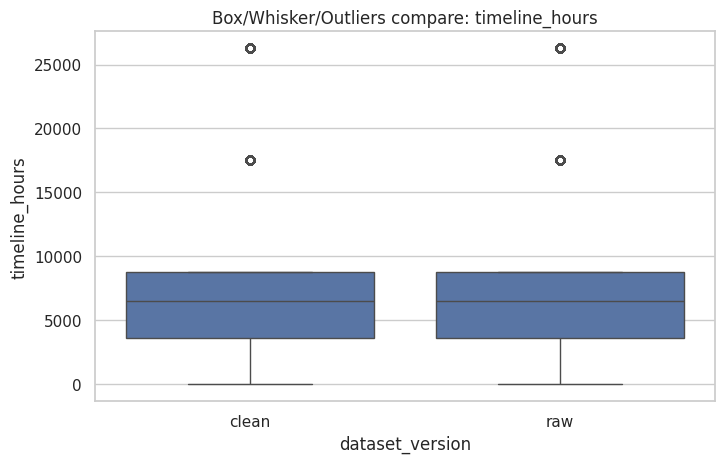

In [7]:
show_box('timeline_hours')


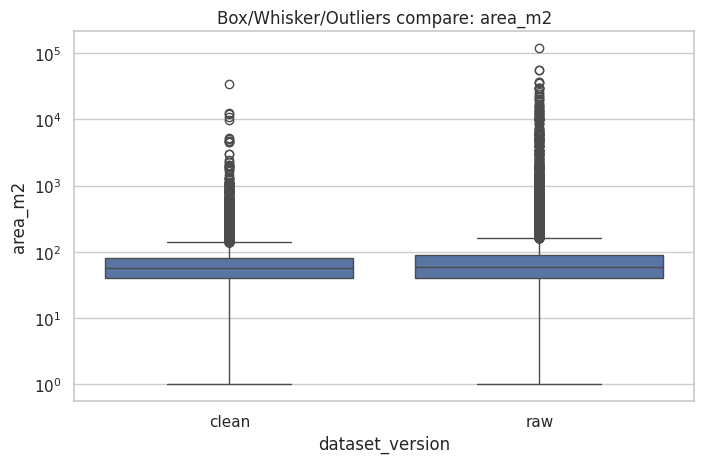

In [8]:
show_box('area_m2')


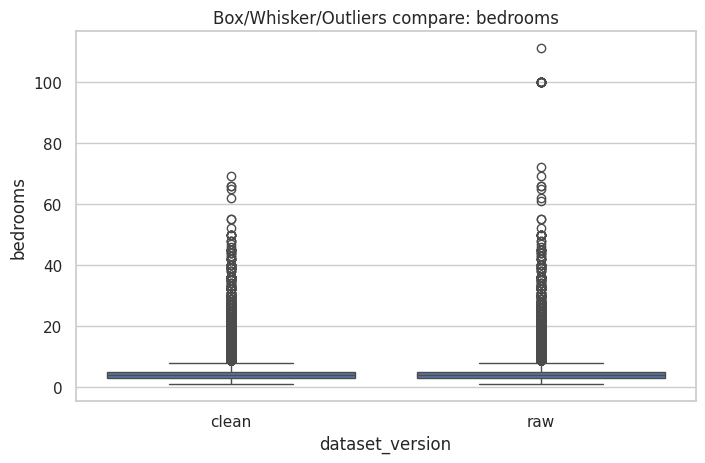

In [9]:
show_box('bedrooms')


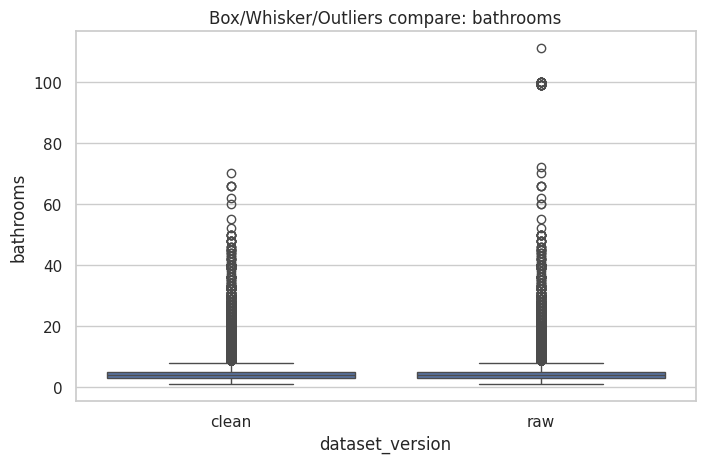

In [10]:
show_box('bathrooms')


In [ ]:
show_box('floors')


In [ ]:
show_box('price_million_vnd')


In [ ]:
if FAST_MODE:
    print('Set FAST_MODE=False and Run All for final conclusions.')
else:
    key_cols = [c for c in ['price_million_vnd', 'area_m2', 'timeline_hours'] if c in raw_df.columns and c in clean_df.columns]
    for col in key_cols:
        rq = raw_df[col].dropna().quantile([0.5, 0.9, 0.99]).to_dict()
        cq = clean_df[col].dropna().quantile([0.5, 0.9, 0.99]).to_dict()
        print(f"\n{col}")
        print('raw  ', {k: round(v, 3) for k, v in rq.items()})
        print('clean', {k: round(v, 3) for k, v in cq.items()})
